In [1]:
import torch

In [2]:
torch.cuda.is_available()

True

In [3]:
from torchsummary import summary

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [5]:
import pandas as pd

In [6]:
import matplotlib.pyplot as plt
import numpy as np

In [7]:
from torch.utils.data import Dataset

In [8]:
from sklearn.model_selection import train_test_split

# Classification with CNN

### Q1: Default Network

In [9]:
batch_size = 8

In [10]:

train_set_x = np.loadtxt("./FashionMNISTwithaTwistW25/x_train.csv", dtype=np.float32, delimiter=",", skiprows=1)
train_set_y = np.loadtxt("./FashionMNISTwithaTwistW25/y_train.csv", dtype=np.float32, delimiter=",", skiprows=1)

# train_set = pd.concat([train_set_x, train_set_y], axis=1)
# train_set = train_set.dropna()

test_x = np.loadtxt("./FashionMNISTwithaTwistW25/x_test.csv", dtype=np.float32, delimiter=",", skiprows=1)
test_y = np.loadtxt("./FashionMNISTwithaTwistW25/y_test.csv", dtype=np.float32, delimiter=",", skiprows=1)

# test_set = pd.concat([test_set_x, test_set_y], axis=1)
# test_set = test_set.dropna()


In [11]:
len(train_set_y)

60000

In [12]:
len(train_set_x)

60000

In [13]:
# train_x = train_set.iloc[:, :-1].to_numpy()
# train_y = train_set.iloc[:, -1].to_numpy()


# test_x = test_set.iloc[:, :-1].to_numpy()
# test_y = test_set.iloc[:, -1].to_numpy()

In [14]:
# train_set.dtypes

In [15]:
train_x, val_x, train_y, val_y = train_test_split(train_set_x, train_set_y, test_size=0.167, random_state=42)

In [16]:
print(train_x.shape)
print(val_x.shape)
print(test_x.shape)
print(test_y.shape)

(49980, 784)
(10020, 784)
(10000, 784)
(10000,)


In [17]:
print(train_y)

[4. 2. 3. ... 2. 2. 1.]


In [18]:
class CSVDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.int64)
        

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idex):
        return self.features[idex], self.labels[idex]
    
train_set = CSVDataset(train_x, train_y)
val_set = CSVDataset(val_x, val_y)
test_set = CSVDataset(test_x, test_y)

In [19]:
features, labels= train_set[1]

print(features)
print(labels)

tensor([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
        139., 201., 198., 134.,  66.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   2.,   0.,   0.,   2.,
          0.,   0.,   0., 102., 132.,  73., 115.,  56., 198.,  49.,   0.,   0.,
          0.,   2.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          2.,   0.,   0.,   0.,  22.,  83., 115., 120., 122.,  90.,  88., 112.,
        122., 127., 137.,  73.,   7.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,  76.,  88.,  76.,  49.,  34.,
         44.,  63.,  76.,  63.,  56.,  61., 110., 100., 110.,  36.,   0.,   2.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   2.,   0.,  24., 132.,
         31.,  39.,  39.,  46.,  29.,  24.,  22.,  24.,  41.,  71.,  61.,  36.,
         78., 127.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,  46.,  73., 100.,  5

Just for the sake of taking a look at the data, lets see what the first sample image is.

tensor(1)


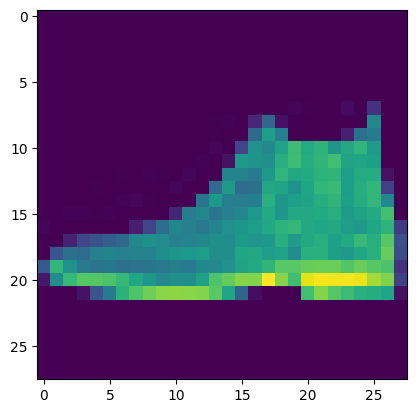

In [20]:
example, label = test_set[0]
plt.imshow(example.reshape(28, 28, 1))
print(label)

Its a shoe!

In [21]:
print(f"Number of batches in the training set: {int(60000/batch_size)}")

Number of batches in the training set: 7500


In [22]:
trainloader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
valloader = torch.utils.data.DataLoader(val_set, batch_size=batch_size, shuffle=False)
testloader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)

In [23]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [24]:
class NeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        # convolutional layer with 32, 3x3 filters, stride 1, padding 1x1
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        # max pooling layer 2,2
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        # convolutional layer with 32, 3x3 filters, stride 1, padding 1x1
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, stride=1, padding=1)
        # output layer: one dense (fully connected) layer 512 nodes
        self.fullconnect = nn.Linear(32 * 7 * 7, 512)
        # a softmax layer with five output values to transform the outputs into a multi-class probability distribution for classification
        self.fullconnect2 = nn.Linear(512, 5)
        self.softmax = nn.Softmax(dim=1)
    def forward(self, x):
        # all internal layer use ReLU

        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool1(x)
        # flatten output
        x = x.view(x.size(0), -1)
        x = F.relu(self.fullconnect(x))
        x = F.relu(self.fullconnect2(x))
        x = self.softmax(x)
        return x


In [25]:
net = NeuralNet()
net.to(device=device)

NeuralNet(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fullconnect): Linear(in_features=1568, out_features=512, bias=True)
  (fullconnect2): Linear(in_features=512, out_features=5, bias=True)
  (softmax): Softmax(dim=1)
)

In [26]:
summary(net, input_size=(1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
         MaxPool2d-2           [-1, 32, 14, 14]               0
            Conv2d-3           [-1, 32, 14, 14]           9,248
         MaxPool2d-4             [-1, 32, 7, 7]               0
            Linear-5                  [-1, 512]         803,328
            Linear-6                    [-1, 5]           2,565
           Softmax-7                    [-1, 5]               0
Total params: 815,461
Trainable params: 815,461
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.30
Params size (MB): 3.11
Estimated Total Size (MB): 3.42
----------------------------------------------------------------


In [27]:
# optimizer : Stochastic Gradient Descent
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

# loss function use categorical crossentropy as the loss function calculated using accuracy as the metric
criterion = nn.CrossEntropyLoss()

In [28]:
for i, data in enumerate(trainloader):
    input, label = data[0].to(device), data[1].to(device)
    input = input.view(input.size(0), 1, 28, 28)
    print(f"imput shape: {input.shape}")
    print(f"after NN: {net(input).shape}")
    break

imput shape: torch.Size([8, 1, 28, 28])
after NN: torch.Size([8, 5])


In [29]:
# import torchvision
# import torchvision.transforms as transforms

In [30]:
# trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
# trainset, valset = torch.utils.data.random_split(trainset, [50000, 10000])

In [31]:
# trainset[0]

In [32]:
# trainloader = torch.utils.data.DataLoader(trainset, batch_size=8, shuffle=True)
# valloader = torch.utils.data.DataLoader(valset, batch_size=8, shuffle=False)

Defining the training loop

In [33]:
training_accuracy = []
validation_accuracy = []

training_loss = []
validation_loss = []

In [34]:
def train_epoch():
    net.train(True)

    counter = 0
    sum_acc = 0
    sum_loss = 0

    running_loss = 0.0
    running_accuracy = 0.0

    for batch_index, data in enumerate(trainloader):
        input, label = data[0].to(device), data[1].to(device)
        input = input.view(input.size(0), 1, 28, 28)
        optimizer.zero_grad()

        output = net(input) # shape [batch_size, 5]

        correct = torch.sum(label == torch.argmax(output, dim=1)).item()

        running_accuracy += correct / batch_size
        loss = criterion(output, label)
        running_loss += loss.item()
        loss.backward()
        optimizer.step()

        if batch_index % 500 == 499: # print every 500 batches
            avg_loss_across_batches = running_loss / 500
            avg_acc_across_batches = (running_accuracy / 500) * 100
            counter += 1
            sum_acc += avg_acc_across_batches
            sum_loss += avg_loss_across_batches
            print('Batch: {0}, loss: {1: .3f}, Accuracy: {2: .1f}%'.format(batch_index+1, avg_loss_across_batches , avg_acc_across_batches))

            running_loss = 0.0
            running_accuracy = 0.0
    training_accuracy.append(sum_acc / counter)
    training_loss.append(sum_loss / counter)
    print()

In [35]:
def val_epoch():
    net.train(False)

    running_loss = 0.0
    running_accuracy = 0.0


    for i, data in enumerate(valloader):
        input, label = data[0].to(device), data[1].to(device)
        input = input.view(input.size(0), 1, 28, 28)

        with torch.no_grad():
            output = net(input) # shape [batch_size, 5]

            correct = torch.sum(label == torch.argmax(output, dim=1)).item()

            running_accuracy += correct / batch_size

            loss = criterion(output, label)
            running_loss += loss.item()

    avg_loss_across_batches = running_loss / len(valloader)
    avg_accuracy_across_batches = (running_accuracy / len(valloader)) * 100

    validation_accuracy.append(avg_accuracy_across_batches)
    validation_loss.append(avg_loss_across_batches)
    print('Val loss: {0: .3f}, Val Accuracy: {1: .1f}%'.format(avg_loss_across_batches , avg_accuracy_across_batches))

    print('*******************************************************************')
    print()



In [36]:
def test_case():
    net.train(False)

    running_loss = 0.0
    running_accuracy = 0.0


    for i, data in enumerate(testloader):
        input, label = data[0].to(device), data[1].to(device)
        input = input.view(input.size(0), 1, 28, 28)

        with torch.no_grad():
            output = net(input) # shape [batch_size, 5]

            correct = torch.sum(label == torch.argmax(output, dim=1)).item()

            running_accuracy += correct / batch_size

            loss = criterion(output, label)
            running_loss += loss.item()

    avg_loss_across_batches = running_loss / len(testloader)
    avg_accuracy_across_batches = (running_accuracy / len(testloader)) * 100

    print('test loss: {0: .3f}, test Accuracy: {1: .1f}%'.format(avg_loss_across_batches , avg_accuracy_across_batches))

    print('*******************************************************************')
    print()

In [37]:
epochs = 10

for epoch in range(epochs):
    print(f'Epoch: {epoch +1}\n')

    train_epoch()
    val_epoch()
    
print("finished training")

Epoch: 1

Batch: 500, loss:  1.277, Accuracy:  64.8%
Batch: 1000, loss:  1.241, Accuracy:  68.9%
Batch: 1500, loss:  1.217, Accuracy:  71.3%
Batch: 2000, loss:  1.169, Accuracy:  77.0%
Batch: 2500, loss:  1.171, Accuracy:  76.4%
Batch: 3000, loss:  1.163, Accuracy:  77.9%
Batch: 3500, loss:  1.166, Accuracy:  77.1%
Batch: 4000, loss:  1.178, Accuracy:  76.0%
Batch: 4500, loss:  1.162, Accuracy:  77.5%
Batch: 5000, loss:  1.160, Accuracy:  77.8%
Batch: 5500, loss:  1.159, Accuracy:  77.7%
Batch: 6000, loss:  1.156, Accuracy:  78.2%

Val loss:  1.155, Val Accuracy:  77.8%
*******************************************************************

Epoch: 2

Batch: 500, loss:  1.156, Accuracy:  78.2%
Batch: 1000, loss:  1.160, Accuracy:  77.8%
Batch: 1500, loss:  1.154, Accuracy:  78.8%
Batch: 2000, loss:  1.154, Accuracy:  77.7%
Batch: 2500, loss:  1.159, Accuracy:  78.1%
Batch: 3000, loss:  1.157, Accuracy:  78.7%
Batch: 3500, loss:  1.158, Accuracy:  78.2%
Batch: 4000, loss:  1.155, Accuracy: 

In [38]:
test_case()

test loss:  1.021, test Accuracy:  88.3%
*******************************************************************



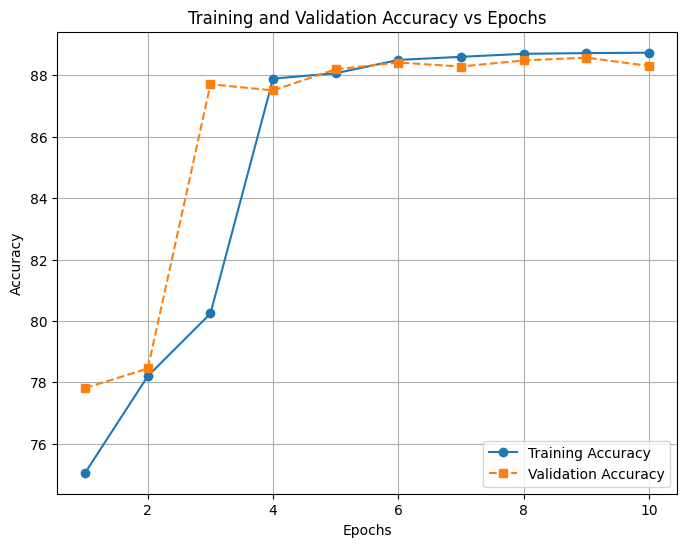

In [39]:
# Example data
epochs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  # Replace with your actual epoch numbers

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(epochs, training_accuracy, label='Training Accuracy', marker='o', linestyle='-')
plt.plot(epochs, validation_accuracy, label='Validation Accuracy', marker='s', linestyle='--')

# Add labels, title, and legend
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy vs Epochs')
plt.legend(loc='best')
plt.grid(True)

# Show the plot
plt.show()

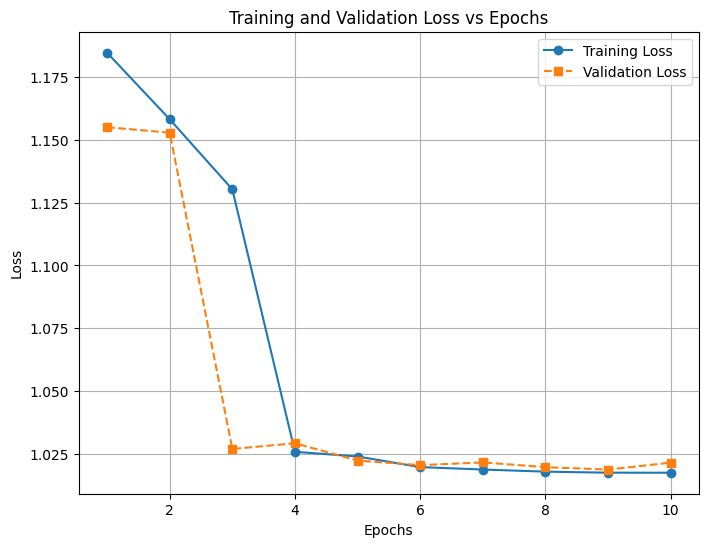

In [40]:
# Example data
epochs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  # Replace with your actual epoch numbers

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(epochs, training_loss, label='Training Loss', marker='o', linestyle='-')
plt.plot(epochs, validation_loss, label='Validation Loss', marker='s', linestyle='--')

# Add labels, title, and legend
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss vs Epochs')
plt.legend(loc='best')
plt.grid(True)

# Show the plot
plt.show()

Pretty Mediocre results, with accuracy only reaching upto ~88%

### Question 2: Our improvements

Things to try:<br>1. Add more layers<br>2. Add drop-out layer<br>3. Change optimizer to Adam<br>4. Perform Hyper-Parameter tuning

In [41]:
batch_size = 8

trainloader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
valloader = torch.utils.data.DataLoader(val_set, batch_size=batch_size, shuffle=False)
testloader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)

In [42]:
class NeuralNet2(nn.Module):
    def __init__(self):
        super().__init__()
        # convolutional layer with 32, 3x3 filters, stride 1, padding 1x1
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=3)
        # max pooling layer 2,2
        self.bn1 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        # convolutional layer with 32, 3x3 filters, stride 1, padding 1x1
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=256, kernel_size=3)
        
        self.bn2 = nn.BatchNorm2d(256)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3)

        self.bn3 = nn.BatchNorm2d(512)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        # flatten the output

        #self.avg_pool = nn.AvgPool2d(5,5)
        self.flatten = nn.Flatten()
        
   
        self.fullconnect1 = nn.Linear(512, 512)
        self.dropout1 = nn.Dropout(p=0.1)

        #self.fullconnect2 = nn.Linear(1024, 512)
        # add a dropout layer
        # self.dropout2 = nn.Dropout(p=0.6)
        # a softmax layer with five output values to transform the outputs into a multi-class probability distribution for classification
        self.fullconnect2 = nn.Linear(512, 5)
        self.mainSoftmax = nn.Softmax(dim=1)
        
    def forward(self, x):
        # all internal layer use ReLU
        x = F.relu(self.conv1(x))
        x = self.bn1(x)
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.bn2(x)
        x = self.pool2(x)
        x = F.relu(self.conv3(x))
        x = self.bn3(x)
        x = self.pool3(x)
        # flatten output
        # x = x.view(x.size(0), -1)
        # x = self.avg_pool(x)
        x = self.flatten(x)
        x = F.relu(self.fullconnect1(x))
        x = self.dropout1(x)
        #x = F.relu(self.fullconnect2(x))
        #x = self.dropout2(x)
        x = F.relu(self.fullconnect2(x))
        x = self.mainSoftmax(x)
        return x

In [43]:
net2 = NeuralNet2()
net2.to(device=device)

NeuralNet2(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(64, 256, kernel_size=(3, 3), stride=(1, 1))
  (bn2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1))
  (bn3): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fullconnect1): Linear(in_features=512, out_features=512, bias=True)
  (dropout1): Dropout(p=0.1, inplace=False)
  (fullconnect2): Linear(in_features=512, out_features=5, bias=True)
  (mainSoftmax): Softmax(dim=1)
)

In [44]:
summary(net2, input_size=(1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 26, 26]             640
       BatchNorm2d-2           [-1, 64, 26, 26]             128
         MaxPool2d-3           [-1, 64, 13, 13]               0
            Conv2d-4          [-1, 256, 11, 11]         147,712
       BatchNorm2d-5          [-1, 256, 11, 11]             512
         MaxPool2d-6            [-1, 256, 5, 5]               0
            Conv2d-7            [-1, 512, 3, 3]       1,180,160
       BatchNorm2d-8            [-1, 512, 3, 3]           1,024
         MaxPool2d-9            [-1, 512, 1, 1]               0
          Flatten-10                  [-1, 512]               0
           Linear-11                  [-1, 512]         262,656
          Dropout-12                  [-1, 512]               0
           Linear-13                    [-1, 5]           2,565
          Softmax-14                   

In [45]:
# optimizer : Adam
optimizer2 = optim.Adam(net2.parameters(), lr=0.001, weight_decay=1e-4)

scheduler = optim.lr_scheduler.StepLR(optimizer2, step_size=2, gamma=0.1)

# loss function use categorical crossentropy as the loss function calculated using accuracy as the metric
criterion = nn.CrossEntropyLoss()

In [46]:
num_params = 0
for x in net2.parameters():
  num_params += len(torch.flatten(x))

print(f'Number of parameters in the model: {num_params:,}')

Number of parameters in the model: 1,595,397


What we changed?<br> Added batch normalization after each convolutional layer.<br> Added a dropout layer<br> used the built in flatten function to flatten the output<br>

In [47]:
training_accuracy = []
validation_accuracy = []

training_loss = []
validation_loss = []

In [48]:
def train_epoch():
    net2.train(True)

    running_loss = 0.0
    # running_accuracy = 0.0
    correct = 0
    total = 0

    counter = 0
    sum_acc = 0
    sum_loss = 0    

    for batch_index, data in enumerate(trainloader):
        input, label = data[0].to(device), data[1].to(device)
        input = input.view(input.size(0), 1, 28, 28)
        
        optimizer2.zero_grad()

        output = net2(input) # shape [batch_size, 5]

        _,predicted = output.max(1)

        # running_accuracy += correct / batch_size

        loss = criterion(output, label)
        loss.backward()
        optimizer2.step()

        running_loss += loss.item()
        correct += predicted.eq(label).sum().item()
        total += label.size(0)

        if batch_index % 500 == 499: # print every 500 batches
            avg_loss_across_batches = running_loss / 500
            avg_acc_across_batches = (correct / total) * 100
            print('Batch: {0}, loss: {1: .3f}, Accuracy: {2: .1f}%'.format(batch_index+1, avg_loss_across_batches , avg_acc_across_batches))
            counter += 1
            sum_acc += avg_acc_across_batches
            sum_loss += avg_loss_across_batches
            running_loss = 0.0
            # running_accuracy = 0.0
            correct = 0
            total = 0
    training_accuracy.append(sum_acc / counter)
    training_loss.append(sum_loss / counter)
    print()
def val_epoch():
    net2.train(False)

    running_loss = 0.0
    #running_accuracy = 0.0
    correct = 0
    total = 0

    for i, data in enumerate(valloader):
        input, label = data[0].to(device), data[1].to(device)
        input = input.view(input.size(0), 1, 28, 28)

        with torch.no_grad():
            output = net2(input) # shape [batch_size, 5]

            _,predicted = output.max(1)

            #running_accuracy += correct / batch_size

            loss = criterion(output, label)
            running_loss += loss.item()
            correct += predicted.eq(label).sum().item()
            total += label.size(0)

    avg_loss_across_batches = running_loss / len(valloader)
    avg_accuracy_across_batches = (correct / total) * 100

    validation_accuracy.append(avg_accuracy_across_batches)
    validation_loss.append(avg_loss_across_batches)
    print('Val loss: {0: .3f}, Val Accuracy: {1: .1f}%'.format(avg_loss_across_batches , avg_accuracy_across_batches))

    print('*******************************************************************')
    print()



In [49]:
def test_case():
    net2.train(False)

    running_loss = 0.0
    #running_accuracy = 0.0
    correct = 0
    total = 0

    for i, data in enumerate(testloader):
        input, label = data[0].to(device), data[1].to(device)
        input = input.view(input.size(0), 1, 28, 28)

        with torch.no_grad():
            output = net2(input) # shape [batch_size, 5]

            _,predicted = output.max(1)

            #running_accuracy += correct / batch_size

            loss = criterion(output, label)
            running_loss += loss.item()
            correct += predicted.eq(label).sum().item()
            total += label.size(0)

    avg_loss_across_batches = running_loss / len(testloader)
    avg_accuracy_across_batches = (correct / total) * 100

    print('Test loss: {0: .3f}, Test Accuracy: {1: .1f}%'.format(avg_loss_across_batches , avg_accuracy_across_batches))

    print('*******************************************************************')
    print()

In [50]:
epochs = 10

for epoch in range(epochs):
    print(f'Epoch: {epoch +1}\n')

    train_epoch()
    val_epoch()

    scheduler.step()
    
print("finished training")

Epoch: 1

Batch: 500, loss:  1.256, Accuracy:  65.8%
Batch: 1000, loss:  1.220, Accuracy:  69.0%
Batch: 1500, loss:  1.150, Accuracy:  78.5%
Batch: 2000, loss:  1.147, Accuracy:  76.5%
Batch: 2500, loss:  1.115, Accuracy:  81.7%
Batch: 3000, loss:  1.117, Accuracy:  81.6%
Batch: 3500, loss:  1.108, Accuracy:  82.3%
Batch: 4000, loss:  1.106, Accuracy:  82.2%
Batch: 4500, loss:  1.124, Accuracy:  80.5%
Batch: 5000, loss:  1.090, Accuracy:  83.5%
Batch: 5500, loss:  1.082, Accuracy:  82.2%
Batch: 6000, loss:  1.062, Accuracy:  84.2%

Val loss:  1.040, Val Accuracy:  86.4%
*******************************************************************

Epoch: 2

Batch: 500, loss:  1.064, Accuracy:  84.1%
Batch: 1000, loss:  1.059, Accuracy:  85.5%
Batch: 1500, loss:  1.045, Accuracy:  87.4%
Batch: 2000, loss:  1.043, Accuracy:  89.3%
Batch: 2500, loss:  1.044, Accuracy:  90.4%
Batch: 3000, loss:  1.037, Accuracy:  91.8%
Batch: 3500, loss:  1.047, Accuracy:  90.1%
Batch: 4000, loss:  1.042, Accuracy: 

In [51]:
test_case()

Test loss:  1.000, Test Accuracy:  96.4%
*******************************************************************



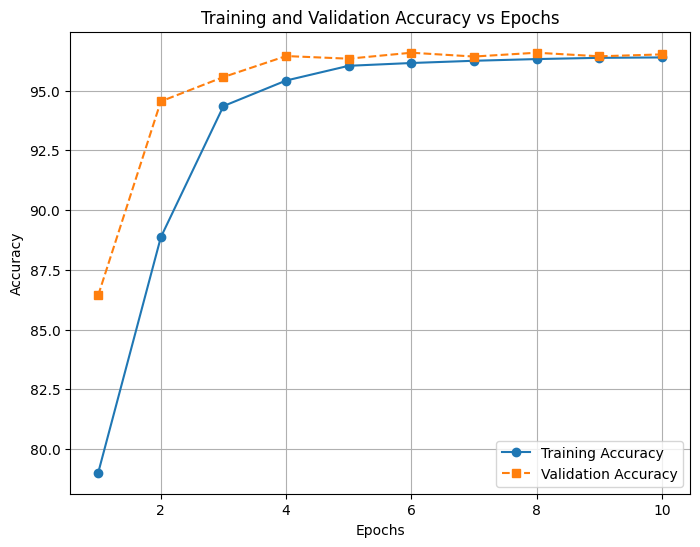

In [52]:
# Example data
epochs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  # Replace with your actual epoch numbers

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(epochs, training_accuracy, label='Training Accuracy', marker='o', linestyle='-')
plt.plot(epochs, validation_accuracy, label='Validation Accuracy', marker='s', linestyle='--')

# Add labels, title, and legend
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy vs Epochs')
plt.legend(loc='best')
plt.grid(True)

# Show the plot
plt.show()

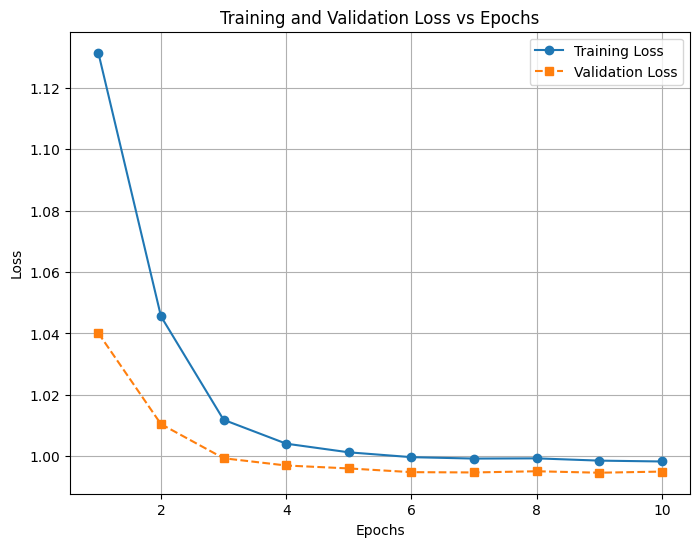

In [53]:
# Example data
epochs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  # Replace with your actual epoch numbers

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(epochs, training_loss, label='Training Loss', marker='o', linestyle='-')
plt.plot(epochs, validation_loss, label='Validation Loss', marker='s', linestyle='--')

# Add labels, title, and legend
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss vs Epochs')
plt.legend(loc='best')
plt.grid(True)

# Show the plot
plt.show()

### Question 4: Use your own Encoding

In [54]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [55]:
encoded_features = []
def hook_fn(module, input, output):
    # global features
    encoded_features.append(output.detach().cpu().numpy())

layer = net2.fullconnect2

handle = layer.register_forward_hook(hook_fn)

inputImages = []
inputImageLabels = []
labels = []

with torch.no_grad():
    for data in testloader:
        input, label = data[0].to(device), data[1].to(device)
        input = input.view(input.size(0), 1, 28, 28)
        for img in input:
            img = img.view(28, 28)
            inputImages.append(img.cpu().numpy())
        for l in label:
            inputImageLabels.append(l.cpu().numpy())   
        _ = net2(input)
        # encoded_features.append(output.cpu().numpy())
        labels.append(label.cpu().numpy())
handle.remove()

In [56]:
# class IntermediateLayerModel(nn.Module):
#     def __init__(self, base_model):
#         super().__init__()
#         self.layer = nn.Sequential(*list(base_model.children())[:-1])

#     def forward(self, x):
#         return self.layer(x)


In [57]:
# encoding_model = IntermediateLayerModel(net2)
# encoding_model.to(device=device)

In [58]:
# encoded_features = []
# inputImages = []
# inputImageLabels = []
# labels = []
# for i, data in enumerate(testloader):
#     input, label = data[0].to(device), data[1].to(device)
#     # inputImages.append(input.cpu().numpy())
#     input = input.view(input.size(0), 1, 28, 28)
#     for img in input:
#         img = img.view(28, 28)
#         inputImages.append(img.cpu().numpy())
#     for l in label:
#         inputImageLabels.append(l.cpu().numpy())    
#     with torch.no_grad():
#         output = encoding_model(input) 
#         encoded_features.append(output.cpu().numpy())
#         labels.append(label.cpu().numpy())


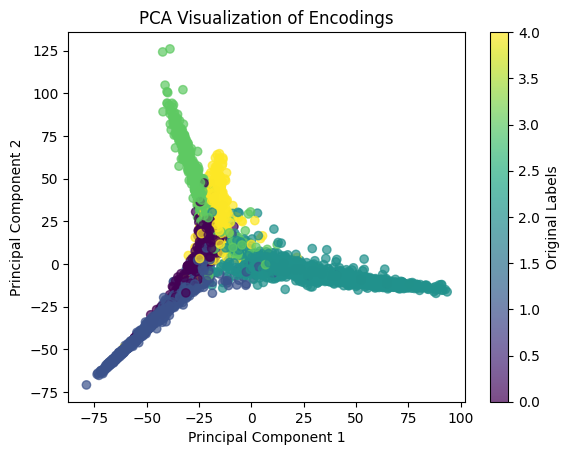

In [59]:
encoded_features = np.concatenate(encoded_features, axis=0)
labels = np.concatenate(labels, axis=0)

# Perform PCA for visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(encoded_features)

# Plot PCA results
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=labels, cmap="viridis", alpha=0.7)
plt.colorbar(label="Original Labels")
plt.title("PCA Visualization of Encodings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

c:\Users\hashi\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\hashi\AppData\Local\Programs\Python\Python38\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\hashi\AppData\Local\Programs\Python\Python38\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\hashi\AppData\Local\Programs\Python\Python38\lib\subprocess.py", line 4

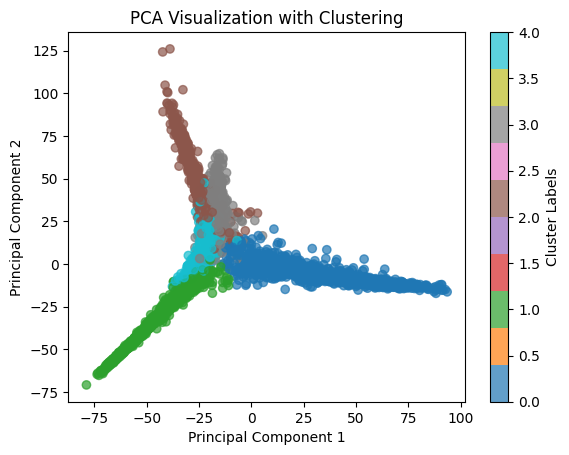

In [60]:
# Perform clustering (e.g., K-means)
kmeans = KMeans(n_clusters=5, random_state=42)
cluster_labels = kmeans.fit_predict(encoded_features)

# Plot PCA with clusters
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=cluster_labels, cmap="tab10", alpha=0.7)
plt.colorbar(label="Cluster Labels")
plt.title("PCA Visualization with Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


In [61]:
from sklearn.manifold import TSNE

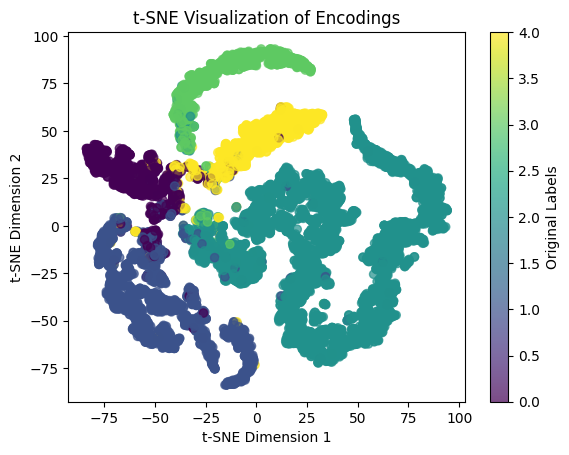

In [62]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_result = tsne.fit_transform(encoded_features)

# Visualize t-SNE results
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=labels, cmap="viridis", alpha=0.7)
plt.colorbar(label="Original Labels")
plt.title("t-SNE Visualization of Encodings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()

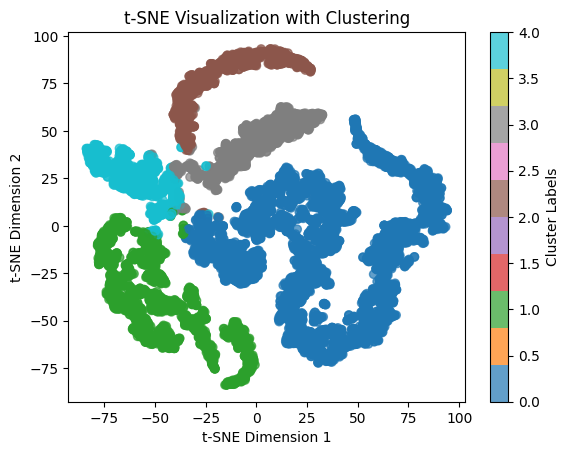

In [63]:
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=cluster_labels, cmap="tab10", alpha=0.7)
plt.colorbar(label="Cluster Labels")
plt.title("t-SNE Visualization with Clustering")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()

Lets See if we can use the clustering above to figure out what the labels of images in each cluster mean

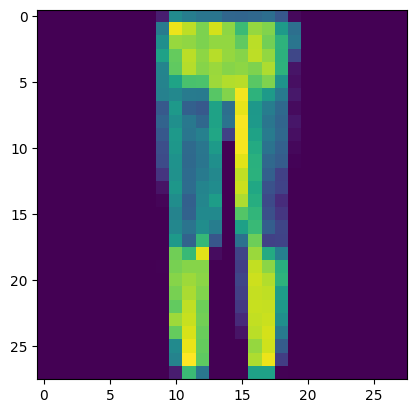

In [64]:
plt.imshow(inputImages[3])

Cluster 0:


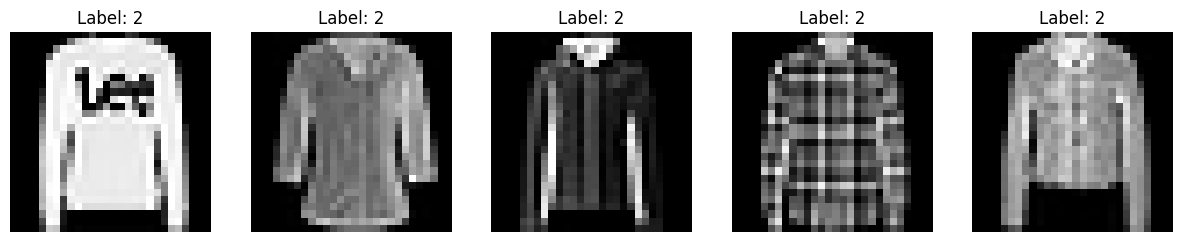

Cluster 1:


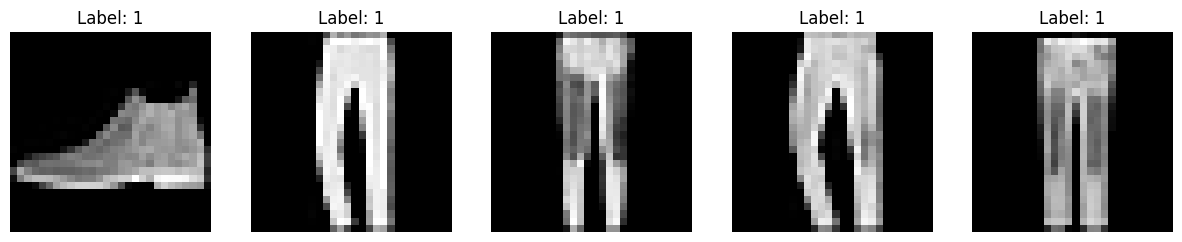

Cluster 2:


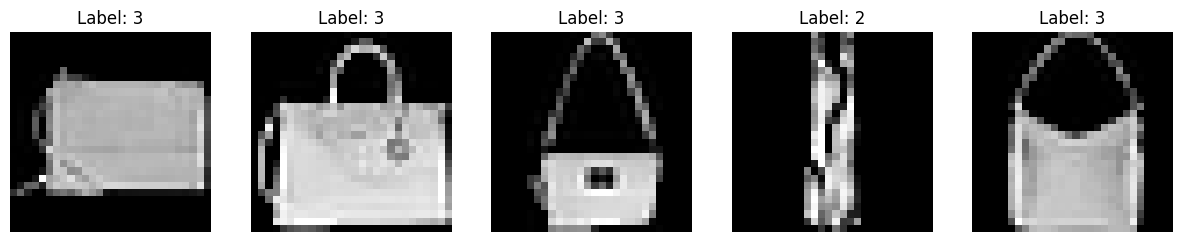

Cluster 3:


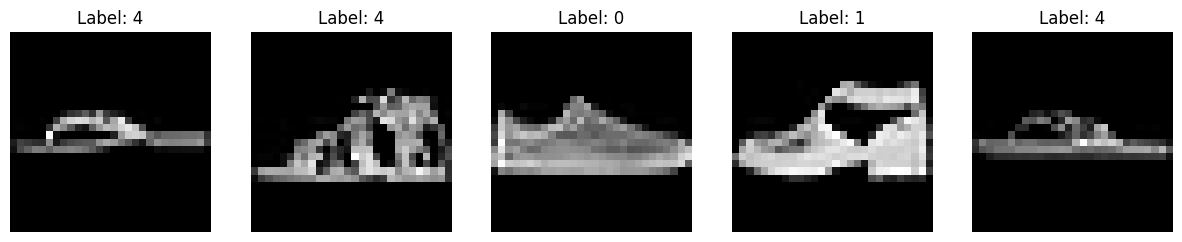

Cluster 4:


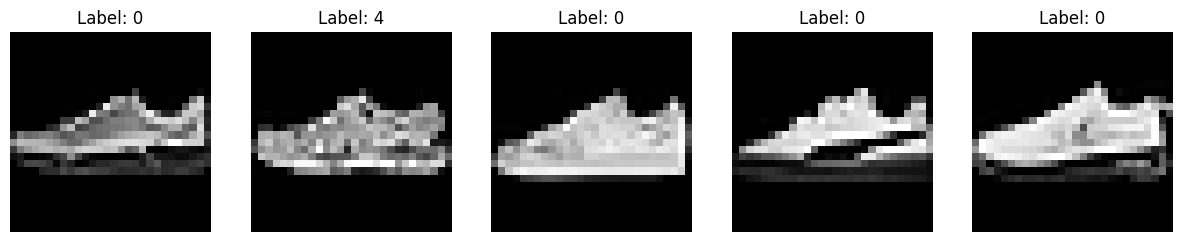

In [65]:
import matplotlib.pyplot as plt

def plot_cluster_examples(images, labels, cluster_labels, num_examples=5):
    unique_clusters = set(cluster_labels)
    for cluster in unique_clusters:
        cluster_indices = [i for i, c in enumerate(cluster_labels) if c == cluster]
        sampled_indices = cluster_indices[:num_examples]  # Take first few examples for simplicity
        
        print(f"Cluster {cluster}:")
        plt.figure(figsize=(15, 3))
        for j, idx in enumerate(sampled_indices):
            plt.subplot(1, num_examples, j + 1)
            plt.imshow(images[idx], cmap="gray") 
            plt.title(f"Label: {labels[idx]}")
            plt.axis("off")
        plt.show()

# Example usage:
plot_cluster_examples(inputImages, inputImageLabels, cluster_labels, num_examples=5)